# 01. Preparation of purified Oedingen sample and generation of embeddings

1. Load the original JSONL.
2. Calculate several signature types for duplicate audit.
3. Build the `leakage_group_id` to prevent similar records from being spread across train/test.
4. Generate a cleaned sample.
5. Save the cleaned dataset.
6. Generate local embeddings for this sample.

## 1. Imports and configurations

In [1]:
!pip -q install transformers sentence-transformers


In [2]:
from pathlib import Path
import ast
import gc
import hashlib
import io
import json
import keyword
import os
import random
import re
import textwrap
import tokenize
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
# =========================
# Main configuration
# =========================

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Kaggle input path
DATA_PATH = Path("/kaggle/input/datasets/caxapb/tda-data/Unformatted_Balanced_Embedded.jsonl")

# Main output folder
OUTPUT_DIR = Path("/kaggle/working/oedingen_human_like_embeddings")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Sampling strategy: "random_groups" or "full_cleaned"
SAMPLING_MODE = "full_cleaned"

# How many leakage-aware groups to sample
N_GROUPS_FOR_SAMPLE = 2500

# Duplicate grouping signature:
DUPLICATE_SIGNATURE_FOR_GROUPS = "ast_signature"

# Cleaning switches
DROP_EXACT_DUPLICATE_ROWS = True
DROP_COMMENTLESS_DUPLICATES_WITHIN_LABEL = False

# Which local embeddings to generate
EMBEDDING_MODELS = [
    "sbert",
    "codebert",
    "graphcodebert",
    "unixcoder",
]

# Runtime settings for transformer embedding generation
BATCH_SIZE = 16
MAX_LENGTH = 512
DEVICE = "cuda" if os.environ.get("CUDA_VISIBLE_DEVICES") not in (None, "") else "cpu"


## 2. Load the original dataset

Columns:
- `id` — task/pair identifier
- `source` — task source
- `code` — code
- `label` — `1 = AI`, `0 = human`
- `embedding` — original Ada embedding from the old dataset

In [4]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset was not found at: {DATA_PATH}")

df_raw = pd.read_json(DATA_PATH, lines=True)
required_columns = {"id", "source", "code", "label", "embedding"}
missing_columns = required_columns - set(df_raw.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df_raw = df_raw.reset_index(drop=True).copy()
df_raw["row_id_original"] = np.arange(len(df_raw))

print("Raw shape:", df_raw.shape)
print(df_raw[["id", "source", "label"]].head())
print()
print("Label counts:")
print(df_raw["label"].value_counts().sort_index())
print()
print("Top sources:")
print(df_raw["source"].value_counts().head(10))


Raw shape: (40158, 6)
                 id source  label
0  HED_HumanEval/20    HED      1
1  HED_HumanEval/20    HED      0
2  HED_HumanEval/38    HED      1
3  HED_HumanEval/38    HED      0
4  HED_HumanEval/39    HED      1

Label counts:
label
0    20079
1    20079
Name: count, dtype: int64

Top sources:
source
CodeContests    18574
APPS            13398
HackerEarth      4100
CodeChef         2342
MBPPD            1264
HED               254
MTrajK            226
Name: count, dtype: int64


In [5]:
df_raw

,id,source,code,label,embedding,row_id_original
0,HED_HumanEval/20,HED,numbers.sort()\n closest_elements = (nu...,1,"[-0.0036959983, -0.0114569357, -0.0021148226, ...",0
1,HED_HumanEval/20,HED,closest_pair = None\n distance = None\n...,0,"[-0.018761592, -0.0229485016, 0.0174498707, -0...",1
2,HED_HumanEval/38,HED,"groups = [s[(3 * i):min((3 * i + 3), len(s...",1,"[0.008215094000000001, 0.0169972107, 0.0059368...",2
3,HED_HumanEval/38,HED,return encode_cyclic(encode_cyclic(s))\n,0,"[7.43296e-05, -0.0027988164, -0.00747543290000...",3
4,HED_HumanEval/39,HED,# First we define a function to check if a...,1,"[0.0077454061, -0.017852217, -0.03440903500000...",4
...,...,...,...,...,...,...
40153,CodeContests_1548_D1. Gregor and the Odd Cows ...,CodeContests,import sys\ninput = lambda: sys.stdin.readline...,0,"[0.0322632119, -0.0027105846, 0.0103345159, 0....",40153
40154,CodeContests_1552_D. Array Differentiation,CodeContests,t = int(input())\n\nfor _ in range(t):\n n ...,1,"[0.023838428800000002, -0.0154414093, 4.6298e-...",40154
40155,CodeContests_1552_D. Array Differentiation,CodeContests,def get_power_set(s):\n power_set=[[]]\n for...,0,"[0.0359626412, -0.0155915609, 0.0139639415, -0...",40155
40156,CodeContests_1557_B. Moamen and k-subarrays,CodeContests,"def can_sort_array(t, test_cases):\n result...",1,"[0.0186608713, 0.0131772552, 0.019931633, -0.0...",40156


In [16]:
print(df_raw.at[0, 'code'])
print('-----')
print(df_raw.at[1, 'code'])
print('-----')
print(df_raw.at[2, 'code'])

    numbers.sort()
    closest_elements = (numbers[0], numbers[1])
    min_difference = numbers[1] - numbers[0]
    
    for i in range(1, len(numbers) - 1):
        difference = numbers[i+1] - numbers[i]
        if difference < min_difference:
            min_difference = difference
            closest_elements = (numbers[i], numbers[i+1])
    
    return closest_elements
-----
    closest_pair = None
    distance = None

    for idx, elem in enumerate(numbers):
        for idx2, elem2 in enumerate(numbers):
            if idx != idx2:
                if distance is None:
                    distance = abs(elem - elem2)
                    closest_pair = tuple(sorted([elem, elem2]))
                else:
                    new_distance = abs(elem - elem2)
                    if new_distance < distance:
                        distance = new_distance
                        closest_pair = tuple(sorted([elem, elem2]))

    return closest_pair

-----
    groups = [s[(3 * i):min((3 * i +

## 3. Quick duplicate audit

We don't want to look only at exactly identical text. We need several levels of "similarity." Below, we'll build four types of signatures:

- `exact_signature` — the text matches exactly;
- `whitespace_signature` — we ignore spaces and empty lines;
- `commentless_signature` — we ignore comments;
- `ast_signature` — we transform the code into a more structured representation.

In [5]:
def sha256_text(text: str) -> str:
    return hashlib.sha256(text.encode("utf-8", errors="ignore")).hexdigest()

def normalize_whitespace(code_text: str) -> str:
    code_text = str(code_text).replace("\r\n", "\n").replace("\r", "\n")
    lines = [line.strip() for line in code_text.split("\n")]
    lines = [line for line in lines if line]
    return "\n".join(lines)

def strip_python_comments(code_text: str) -> str:
    try:
        out = []
        reader = io.StringIO(str(code_text)).readline
        for tok in tokenize.generate_tokens(reader):
            if tok.type == tokenize.COMMENT:
                continue
            if tok.type in {tokenize.NL, tokenize.NEWLINE}:
                out.append("\n")
            else:
                out.append(tok.string)
        return " ".join(out)
    except Exception:
        return normalize_whitespace(code_text)

class IdentifierNormalizer(ast.NodeTransformer):
    def __init__(self):
        self.name_map = {}
        self.counter = 0

    def _new_name(self, old_name: str) -> str:
        if old_name not in self.name_map:
            self.name_map[old_name] = f"VAR_{self.counter}"
            self.counter += 1
        return self.name_map[old_name]

    def visit_Name(self, node):
        node.id = self._new_name(node.id)
        return node

    def visit_arg(self, node):
        node.arg = self._new_name(node.arg)
        return node

    def visit_FunctionDef(self, node):
        node.name = self._new_name(node.name)
        self.generic_visit(node)
        return node

    def visit_AsyncFunctionDef(self, node):
        node.name = self._new_name(node.name)
        self.generic_visit(node)
        return node

    def visit_ClassDef(self, node):
        node.name = self._new_name(node.name)
        self.generic_visit(node)
        return node

def parse_python_snippet(code_text: str):
    clean = textwrap.dedent(str(code_text)).strip("\n")
    try:
        return ast.parse(clean)
    except SyntaxError:
        wrapped = "def _snippet_wrapper():\n" + textwrap.indent(clean, "    ")
        try:
            return ast.parse(wrapped)
        except SyntaxError:
            return None

def ast_normalized_text(code_text: str) -> str:
    tree = parse_python_snippet(code_text)
    if tree is None:
        return strip_python_comments(code_text)
    tree = IdentifierNormalizer().visit(tree)
    ast.fix_missing_locations(tree)
    return ast.dump(tree, annotate_fields=True, include_attributes=False)

df_sig = df_raw.copy()
df_sig["exact_signature"] = df_sig["code"].map(sha256_text)
df_sig["whitespace_signature"] = df_sig["code"].map(lambda x: sha256_text(normalize_whitespace(x)))
df_sig["commentless_signature"] = df_sig["code"].map(lambda x: sha256_text(strip_python_comments(x)))
df_sig["ast_signature"] = df_sig["code"].map(lambda x: sha256_text(ast_normalized_text(x)))

signature_columns = [
    "exact_signature",
    "whitespace_signature",
    "commentless_signature",
    "ast_signature",
]

audit_rows = []
for col in signature_columns:
    counts = df_sig[col].value_counts()
    duplicate_rows = int(counts[counts > 1].sum())
    duplicate_families = int((counts > 1).sum())
    cross_id_duplicate_families = 0

    for sig in counts[counts > 1].index:
        if df_sig.loc[df_sig[col] == sig, "id"].nunique() > 1:
            cross_id_duplicate_families += 1

    audit_rows.append(
        {
            "signature_type": col,
            "duplicate_rows": duplicate_rows,
            "duplicate_families": duplicate_families,
            "cross_id_duplicate_families": cross_id_duplicate_families,
        }
    )

audit_df = pd.DataFrame(audit_rows)
audit_df


<unknown>:7: SyntaxWarning: invalid escape sequence '\.'
<unknown>:4: SyntaxWarning: invalid escape sequence '\w'
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:3: SyntaxWarning: invalid escape sequence '\d'
<unknown>:4: SyntaxWarning: invalid escape sequence '\D'
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:4: SyntaxWarning: invalid escape sequence '\Z'
<unknown>:83: SyntaxWarning: invalid escape sequence '\`'
<unknown>:4: SyntaxWarning: invalid escape sequence '\d'
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:3: SyntaxWarning: invalid escape sequence '\s'
<unknown>:4: SyntaxWarning: invalid escape sequence '\$'
<unknown>:1: SyntaxWarning: invalid escape sequence '\w'
<unknown>:2: SyntaxWarning: invalid escape sequence '\/'
<unknown

,signature_type,duplicate_rows,duplicate_families,cross_id_duplicate_families
0,exact_signature,4,2,1
1,whitespace_signature,1533,713,116
2,commentless_signature,1187,565,68
3,ast_signature,6566,2584,479


## 4. Building leakage-aware groups

If two different `id`s are related by the same signature, we consider them to be a single "family of similar solutions".
Then the train/test split will be based not on the original `id`, but on the `leakage_group_id`.

In [6]:
class UnionFind:
    def __init__(self, items):
        self.parent = {x: x for x in items}
        self.rank = {x: 0 for x in items}

    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, a, b):
        ra = self.find(a)
        rb = self.find(b)
        if ra == rb:
            return
        if self.rank[ra] < self.rank[rb]:
            self.parent[ra] = rb
        elif self.rank[ra] > self.rank[rb]:
            self.parent[rb] = ra
        else:
            self.parent[rb] = ra
            self.rank[ra] += 1

if DUPLICATE_SIGNATURE_FOR_GROUPS not in signature_columns:
    raise ValueError(f"Unknown signature for grouping: {DUPLICATE_SIGNATURE_FOR_GROUPS}")

uf = UnionFind(df_sig["id"].unique().tolist())
id_lists = df_sig.groupby(DUPLICATE_SIGNATURE_FOR_GROUPS)["id"].agg(lambda x: sorted(set(x)))

for ids in id_lists:
    if len(ids) > 1:
        root = ids[0]
        for other in ids[1:]:
            uf.union(root, other)

df_clean = df_sig.copy()
df_clean["leakage_group_id"] = df_clean["id"].map(lambda x: uf.find(x))

print("Unique original ids:", df_clean["id"].nunique())
print("Unique leakage-aware groups:", df_clean["leakage_group_id"].nunique())
print()
print(df_clean[["id", "leakage_group_id"]].head())


Unique original ids: 6899
Unique leakage-aware groups: 6492

                 id  leakage_group_id
0  HED_HumanEval/20  HED_HumanEval/20
1  HED_HumanEval/20  HED_HumanEval/20
2  HED_HumanEval/38  HED_HumanEval/38
3  HED_HumanEval/38  HED_HumanEval/38
4  HED_HumanEval/39  HED_HumanEval/39


## 5. Clean and download cleaned sample


In [7]:
rows_before = len(df_clean)

if DROP_EXACT_DUPLICATE_ROWS:
    df_clean = df_clean.drop_duplicates(subset=["exact_signature", "label"]).copy()

if DROP_COMMENTLESS_DUPLICATES_WITHIN_LABEL:
    df_clean = df_clean.sort_values(["commentless_signature", "row_id_original"]).drop_duplicates(
        subset=["commentless_signature", "label"], keep="first"
    ).copy()

rows_after = len(df_clean)

print("Rows before cleaning:", rows_before)
print("Rows after cleaning:", rows_after)
print("Label counts after cleaning:")
print(df_clean["label"].value_counts().sort_index())

if SAMPLING_MODE == "full_cleaned":
    df_sample = df_clean.sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)
elif SAMPLING_MODE == "random_groups":
    all_groups = np.array(sorted(df_clean["leakage_group_id"].unique()))
    n_groups = min(N_GROUPS_FOR_SAMPLE, len(all_groups))
    selected = np.random.default_rng(RANDOM_SEED).choice(all_groups, size=n_groups, replace=False)
    df_sample = df_clean[df_clean["leakage_group_id"].isin(set(selected))].copy()
    df_sample = df_sample.sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)
else:
    raise ValueError(f"Unknown SAMPLING_MODE: {SAMPLING_MODE}")

print()
print("Sample shape:", df_sample.shape)
print("Sample label counts:")
print(df_sample["label"].value_counts().sort_index())
print("Unique ids:", df_sample["id"].nunique())
print("Unique leakage groups:", df_sample["leakage_group_id"].nunique())


Rows before cleaning: 40158
Rows after cleaning: 40156
Label counts after cleaning:
label
0    20078
1    20078
Name: count, dtype: int64

Sample shape: (15679, 11)
Sample label counts:
label
0    7839
1    7840
Name: count, dtype: int64
Unique ids: 2664
Unique leakage groups: 2500


In [8]:
# Save cleaned sample in two versions:
# 1) with original Ada embeddings
# 2) without Ada embeddings

sample_with_ada_path = OUTPUT_DIR / "oedingen_cleaned_sample_with_ada.jsonl"
sample_without_ada_path = OUTPUT_DIR / "oedingen_cleaned_sample_no_ada.jsonl"

df_sample.to_json(sample_with_ada_path, orient="records", lines=True)
df_sample.drop(columns=["embedding"]).to_json(sample_without_ada_path, orient="records", lines=True)

sample_metadata = {
    "n_rows": int(len(df_sample)),
    "n_ids": int(df_sample["id"].nunique()),
    "n_leakage_groups": int(df_sample["leakage_group_id"].nunique()),
    "label_counts": {str(k): int(v) for k, v in df_sample["label"].value_counts().sort_index().items()},
    "source_counts": {str(k): int(v) for k, v in df_sample["source"].value_counts().items()},
    "sampling_mode": SAMPLING_MODE,
    "random_seed": RANDOM_SEED,
    "duplicate_signature_for_groups": DUPLICATE_SIGNATURE_FOR_GROUPS,
}
with open(OUTPUT_DIR / "sample_metadata.json", "w", encoding="utf-8") as f:
    json.dump(sample_metadata, f, indent=2)

audit_df.to_csv(OUTPUT_DIR / "duplicate_audit_summary.csv", index=False)

print("Saved:", sample_with_ada_path)
print("Saved:", sample_without_ada_path)
print("Saved:", OUTPUT_DIR / "sample_metadata.json")
print("Saved:", OUTPUT_DIR / "duplicate_audit_summary.csv")


Saved: /kaggle/working/oedingen_human_like_embeddings/oedingen_cleaned_sample_with_ada.jsonl
Saved: /kaggle/working/oedingen_human_like_embeddings/oedingen_cleaned_sample_no_ada.jsonl
Saved: /kaggle/working/oedingen_human_like_embeddings/sample_metadata.json
Saved: /kaggle/working/oedingen_human_like_embeddings/duplicate_audit_summary.csv


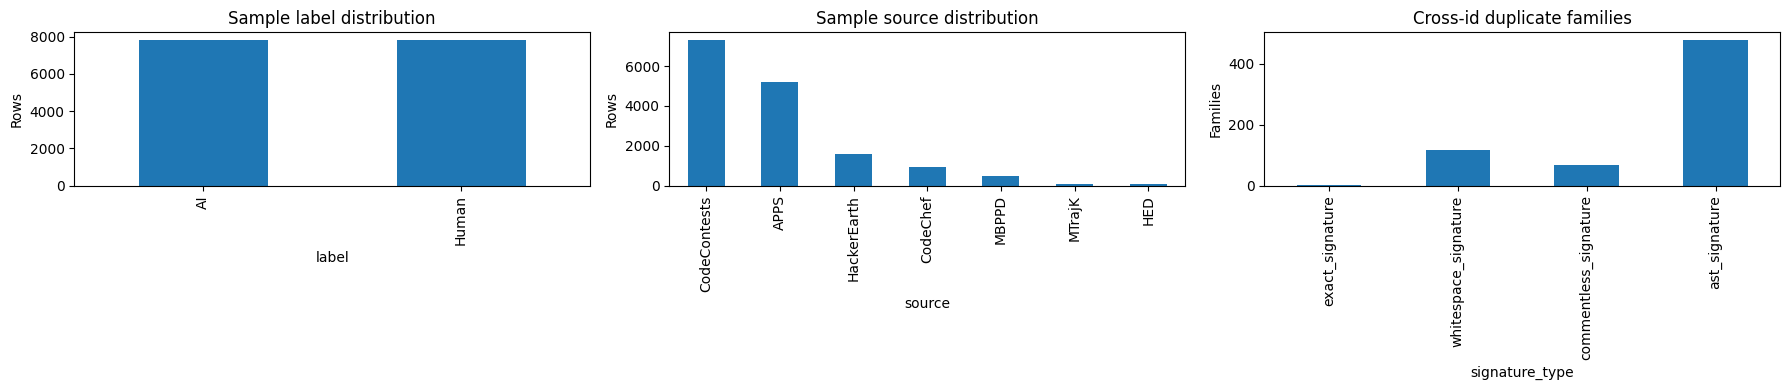

Saved: /kaggle/working/oedingen_human_like_embeddings/duplicate_audit_and_sample_overview.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

df_sample["label"].map({0: "Human", 1: "AI"}).value_counts().plot(kind="bar", ax=axes[0], title="Sample label distribution")
axes[0].set_ylabel("Rows")

df_sample["source"].value_counts().plot(kind="bar", ax=axes[1], title="Sample source distribution")
axes[1].set_ylabel("Rows")

audit_df.set_index("signature_type")["cross_id_duplicate_families"].plot(kind="bar", ax=axes[2], title="Cross-id duplicate families")
axes[2].set_ylabel("Families")

plt.tight_layout()
fig_path = OUTPUT_DIR / "duplicate_audit_and_sample_overview.png"
plt.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)


## 7. Download Ada embeddings


In [10]:
ada_matrix = np.array(df_sample["embedding"].tolist(), dtype=np.float32)
np.save(OUTPUT_DIR / "ada_embeddings.npy", ada_matrix)

print("Ada matrix shape:", ada_matrix.shape)
print("Saved:", OUTPUT_DIR / "ada_embeddings.npy")


Ada matrix shape: (15679, 1536)
Saved: /kaggle/working/oedingen_human_like_embeddings/ada_embeddings.npy


## 8. Generating Local Embeddings


In [11]:
MODEL_NAMES = {
    "sbert": "sentence-transformers/all-MiniLM-L6-v2",
    "codebert": "microsoft/codebert-base",
    "graphcodebert": "microsoft/graphcodebert-base",
    "unixcoder": "microsoft/unixcoder-base",
}

sample_codes = df_sample["code"].astype(str).tolist()


In [12]:
from tqdm.auto import tqdm

def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = (last_hidden_state * mask).sum(dim=1)
    denom = mask.sum(dim=1).clamp(min=1e-9)
    return summed / denom

def generate_sentence_transformer_embeddings(texts, model_name, batch_size=16):
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(model_name, device=DEVICE)
    vecs = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=False,
    )
    return np.asarray(vecs, dtype=np.float32)

def generate_transformer_embeddings(texts, model_name, batch_size=16, max_length=512):
    import torch
    from transformers import AutoTokenizer, AutoModel

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model.to(DEVICE)
    model.eval()

    vectors = []
    with torch.no_grad():
        for start in tqdm(range(0, len(texts), batch_size), desc=f"Embedding {model_name}"):
            batch = texts[start:start + batch_size]
            enc = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt",
            )
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            out = model(**enc)
            pooled = mean_pool(out.last_hidden_state, enc["attention_mask"])
            vectors.append(pooled.detach().cpu().numpy().astype(np.float32))

    return np.vstack(vectors)

for name in EMBEDDING_MODELS:
    if name not in MODEL_NAMES:
        print(f"Skipping unknown embedding model: {name}")
        continue

    print("\n" + "=" * 80)
    print("Generating embeddings for:", name)
    print("=" * 80)

    if name == "sbert":
        matrix = generate_sentence_transformer_embeddings(
            sample_codes,
            MODEL_NAMES[name],
            batch_size=BATCH_SIZE,
        )
    else:
        matrix = generate_transformer_embeddings(
            sample_codes,
            MODEL_NAMES[name],
            batch_size=BATCH_SIZE,
            max_length=MAX_LENGTH,
        )

    save_path = OUTPUT_DIR / f"{name}_embeddings.npy"
    np.save(save_path, matrix)

    print("Shape:", matrix.shape)
    print("Saved:", save_path)

    del matrix
    gc.collect()



Generating embeddings for: sbert


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: microsoft/unixcoder-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding microsoft/unixcoder-base:   0%|          | 0/980 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/504M [00:00<?, ?B/s]

Shape: (15679, 768)
Saved: /kaggle/working/oedingen_human_like_embeddings/unixcoder_embeddings.npy


## 9.Manifest


In [13]:
manifest = {
    "output_dir": str(OUTPUT_DIR),
    "sample_path_with_ada": str(sample_with_ada_path),
    "sample_path_without_ada": str(sample_without_ada_path),
    "sampling_mode": SAMPLING_MODE,
    "n_rows": int(len(df_sample)),
    "n_ids": int(df_sample["id"].nunique()),
    "n_leakage_groups": int(df_sample["leakage_group_id"].nunique()),
    "generated_embeddings": EMBEDDING_MODELS,
    "max_length": MAX_LENGTH,
    "batch_size": BATCH_SIZE,
}
with open(OUTPUT_DIR / "manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print(json.dumps(manifest, indent=2))
print("Saved:", OUTPUT_DIR / "manifest.json")


{
  "output_dir": "/kaggle/working/oedingen_human_like_embeddings",
  "sample_path_with_ada": "/kaggle/working/oedingen_human_like_embeddings/oedingen_cleaned_sample_with_ada.jsonl",
  "sample_path_without_ada": "/kaggle/working/oedingen_human_like_embeddings/oedingen_cleaned_sample_no_ada.jsonl",
  "sampling_mode": "random_groups",
  "n_rows": 15679,
  "n_ids": 2664,
  "n_leakage_groups": 2500,
  "generated_embeddings": [
    "sbert",
    "codebert",
    "graphcodebert",
    "unixcoder"
  ],
  "max_length": 512,
  "batch_size": 16
}
Saved: /kaggle/working/oedingen_human_like_embeddings/manifest.json
